# Exploratory Data Analysis: Netflix Catalog Analysis

This notebook presents an advanced exploratory data analysis and statistical investigation into the Netflix titles catalog (`NetFlix.csv`).

### Research Objectives:
1. **Movie Runtime Evolution:** Analyze historical trends in movie runtimes from the 1960s to the 2020s, and perform parametric and non-parametric hypothesis tests (Welch's t-test, Kruskal-Wallis).
2. **TV Series Longevity & Survival Cliff:** Quantify season drop-off rates and distribution dynamics across serialized television content.
3. **Multivariate OLS Regression:** Estimate the impact of release year, content rating, and genre indicators on movie runtimes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Visual settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## 0. Data Ingestion & Preprocessing

In [ ]:
# Load the dataset
df = pd.read_csv('NetFlix.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Dataset Shape: 7787 rows, 12 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [ ]:
# Inspect missing values
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0])

Missing Values per Column:
director      2389
cast           718
country        507
date_added      10
rating           7
dtype: int64


Null rows are mostly come from which the director is missing (which is extremely common for documentaries, TV series, reality TV, and acquired international programming).

Removing them would introduce survival bias into the runtime analysis because it would lead to accidentally delete thousands of legitimate movies and TV shows whose durations are perfectly intact.

In [ ]:
# Feature engineering: Add decade and parse clean datetime
df['decade'] = (df['release_year'] // 10) * 10
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Separate Movies and TV Shows
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

print(f"Total Movies: {len(movies)}")
print(f"Total TV Shows: {len(tv_shows)}")

Total Movies: 5377
Total TV Shows: 2410


/tmp/ipykernel_1559/2741894169.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')


## 1. Movie Runtime Evolution Across Decades (1960s – 2020s)

Does modern streaming favor shorter runtimes? I will compute aggregate summary metrics across decades and test whether the compression between eras is statistically significant.

In [ ]:
# Aggregate runtime statistics by decade
runtime_by_decade = movies[movies['decade'] >= 1960].groupby('decade')['duration'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std'
).reset_index()

runtime_by_decade

,decade,Count,Mean,Median,Std
0,1960,22,142.363636,141.5,40.359746
1,1970,63,119.111111,112.0,37.378669
2,1980,99,116.434343,104.0,35.695756
3,1990,194,113.917526,108.0,34.195921
4,2000,601,112.637271,108.0,28.312451
5,2010,3951,96.762086,96.0,25.961609
6,2020,423,89.522459,94.0,31.366490


In [ ]:
# Hypothesis Testing across Decades
d_2000 = movies[movies['decade'] == 2000]['duration']
d_2010 = movies[movies['decade'] == 2010]['duration']
d_2020 = movies[movies['decade'] == 2020]['duration']

# Welch's two-sample t-test (2000s vs 2010s)
ttest_res = stats.ttest_ind(d_2000, d_2010, equal_var=False)

# Non-parametric Kruskal-Wallis test across 2000s, 2010s, 2020s
kw_res = stats.kruskal(d_2000, d_2010, d_2020)

print(f"Welch's t-test (2000s vs 2010s): t = {ttest_res.statistic:.4f}, p = {ttest_res.pvalue:.4e}")
print(f"Kruskal-Wallis test (2000s, 2010s, 2020s): H = {kw_res.statistic:.4f}, p = {kw_res.pvalue:.4e}")

Welch's t-test (2000s vs 2010s): t = 12.9432, p = 8.9068e-35
Kruskal-Wallis test (2000s, 2010s, 2020s): H = 182.0766, p = 2.9011e-40


## 2. TV Show Longevity & Season Drop-off Analysis

In [ ]:
# Season counts and survival percentages
season_counts = tv_shows['duration'].value_counts().sort_index()
season_summary = pd.DataFrame({
    'Total Shows': season_counts,
    'Percentage (%)': (season_counts / len(tv_shows) * 100).round(2)
})
season_summary.head(10)

,Total Shows,Percentage (%)
duration,,
1,1608,66.72
2,382,15.85
3,184,7.63
4,87,3.61
5,58,2.41
6,30,1.24
7,19,0.79
8,18,0.75
9,8,0.33


/tmp/ipykernel_1559/2931363022.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1559/2931363022.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_seasons.index, y=top_seasons.values, ax=axes[1], palette='Reds_r')


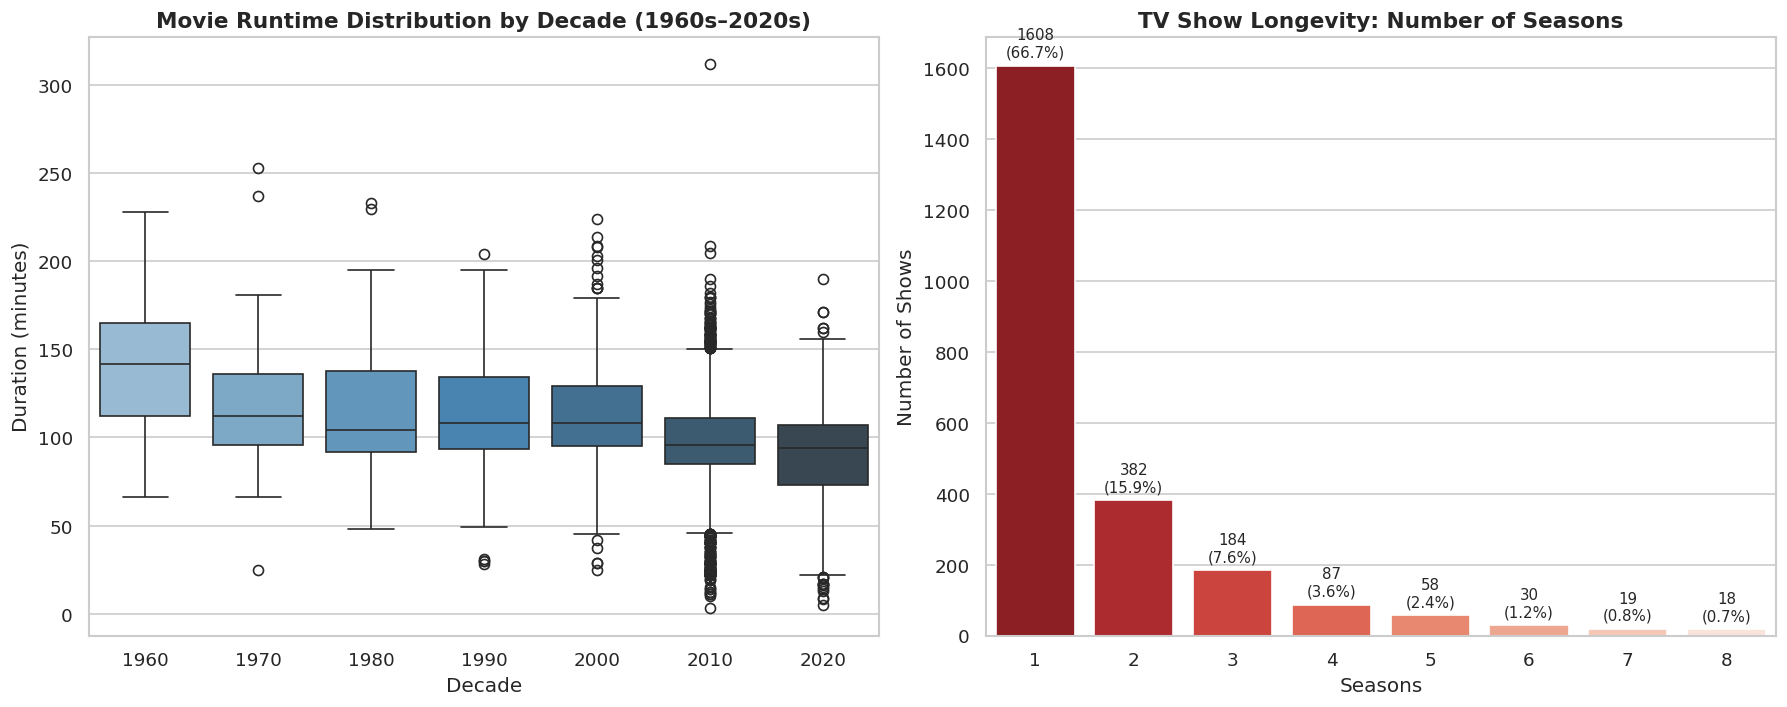

In [ ]:
# Plotting Runtime Distribution & TV Longevity Cliff
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Boxplot of Movie Runtime by Decade
movies_filtered = movies[(movies['decade'] >= 1960) & (movies['decade'] <= 2020)]
sns.boxplot(
    data=movies_filtered,
    x='decade',
    y='duration',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Movie Runtime Distribution by Decade (1960s–2020s)', fontsize=13, weight='bold')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Duration (minutes)')

# Subplot 2: TV Show Season Drop-Off
top_seasons = season_counts.head(8)
sns.barplot(x=top_seasons.index, y=top_seasons.values, ax=axes[1], palette='Reds_r')
axes[1].set_title('TV Show Longevity: Number of Seasons', fontsize=13, weight='bold')
axes[1].set_xlabel('Seasons')
axes[1].set_ylabel('Number of Shows')

for i, v in enumerate(top_seasons.values):
    axes[1].text(i, v + 25, f"{v}\n({v/len(tv_shows)*100:.1f}%)", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3. Multivariate OLS Regression: Predictors of Movie Duration

I model movie duration as a function of `release_year`, content maturity `rating`, and primary genre tags to measure their relative effects on film length.

In [ ]:
# Prepare data for regression
reg_df = movies.dropna(subset=['rating', 'duration', 'release_year']).copy()

# Filter to prominent ratings to avoid sparse categories
common_ratings = ['TV-MA', 'TV-14', 'R', 'TV-PG', 'PG-13', 'PG']
reg_df = reg_df[reg_df['rating'].isin(common_ratings)]

# Create binary indicators for key genres
reg_df['is_drama'] = reg_df['genres'].str.contains('Dramas', case=False, na=False).astype(int)
reg_df['is_comedy'] = reg_df['genres'].str.contains('Comedies', case=False, na=False).astype(int)
reg_df['is_action'] = reg_df['genres'].str.contains('Action & Adventure', case=False, na=False).astype(int)
reg_df['is_documentary'] = reg_df['genres'].str.contains('Documentaries', case=False, na=False).astype(int)
reg_df['is_children'] = reg_df['genres'].str.contains('Children & Family', case=False, na=False).astype(int)

# Fit Ordinary Least Squares (OLS) model
model = smf.ols(
    'duration ~ release_year + C(rating) + is_drama + is_comedy + is_action + is_documentary + is_children',
    data=reg_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               duration   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     164.4
Date:                Wed, 30 Sep 2026   Prob (F-statistic):          4.94e-324
Time:                        08:41:42   Log-Likelihood:                -22385.
No. Observations:                4918   AIC:                         4.479e+04
Df Residuals:                    4906   BIC:                         4.487e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            796.7920     71